# EDA - Base de películas IMDB (TP Grupal)

Análisis exploratorio de `movie.sqlite`: características generales del dataset,
tipos de variables, estadística descriptiva y relaciones. Sirve de base para las
diapositivas del grupo.

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Carga desde SQLite e inspección

La base tiene 3 tablas relacionadas por `Movie_id`.

In [2]:
con = sqlite3.connect("movie.sqlite")
tablas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)
print(tablas["name"].tolist())

imdb = pd.read_sql("SELECT * FROM IMDB", con)
earning = pd.read_sql("SELECT * FROM earning", con)
genre = pd.read_sql("SELECT * FROM genre", con)
con.close()

print("IMDB:", imdb.shape, "| earning:", earning.shape, "| genre:", genre.shape)

['IMDB', 'earning', 'genre']
IMDB: (117, 52) | earning: (117, 3) | genre: (351, 2)


In [3]:
imdb.iloc[:, :8].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Movie_id    117 non-null    object 
 1   Title       117 non-null    object 
 2   Rating      117 non-null    float64
 3   TotalVotes  117 non-null    int64  
 4   MetaCritic  117 non-null    object 
 5   Budget      117 non-null    object 
 6   Runtime     117 non-null    object 
 7   CVotes10    117 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 7.4+ KB


### Diccionario de datos

Qué representa cada campo de las 3 tablas. La mayoría de las columnas de `IMDB` son
el voto desagregado por demografía, con dos prefijos: **`CVotes*`** = *cantidad* de
votos de ese grupo y **`Votes*`** = *rating promedio* que dio ese grupo.

In [4]:
# Diccionario de datos: qué representa cada campo
# Convención: CVotes* = CANTIDAD de votos de un grupo | Votes* = RATING PROMEDIO de ese grupo
desc = {
    # --- IMDB: contenido ---
    "Movie_id": "Identificador único de la película (clave para unir las 3 tablas)",
    "Title": "Título de la película (incluye el año)",
    "Rating": "Calificación promedio en IMDB (escala 0-10)",
    "TotalVotes": "Cantidad total de votos recibidos en IMDB",
    "MetaCritic": "Puntaje de Metacritic (escala 0-100)",
    "Budget": "Presupuesto de producción (USD)",
    "Runtime": "Duración de la película (minutos)",
    # --- IMDB: cantidad de votos por puntaje otorgado ---
    **{f"CVotes{n:02d}": f"Cantidad de votos con puntaje {n}" for n in range(10, 0, -1)},
    # --- IMDB: cantidad de votos por género ---
    "CVotesMale": "Cantidad de votos de usuarios varones",
    "CVotesFemale": "Cantidad de votos de usuarias mujeres",
    # --- IMDB: cantidad de votos por edad (y género) ---
    "CVotesU18": "Cantidad de votos de menores de 18 años",
    "CVotesU18M": "Cantidad de votos de varones menores de 18 años",
    "CVotesU18F": "Cantidad de votos de mujeres menores de 18 años",
    "CVotes1829": "Cantidad de votos de usuarios de 18 a 29 años",
    "CVotes1829M": "Cantidad de votos de varones de 18 a 29 años",
    "CVotes1829F": "Cantidad de votos de mujeres de 18 a 29 años",
    "CVotes3044": "Cantidad de votos de usuarios de 30 a 44 años",
    "CVotes3044M": "Cantidad de votos de varones de 30 a 44 años",
    "CVotes3044F": "Cantidad de votos de mujeres de 30 a 44 años",
    "CVotes45A": "Cantidad de votos de usuarios de 45 años o más",
    "CVotes45AM": "Cantidad de votos de varones de 45 años o más",
    "CVotes45AF": "Cantidad de votos de mujeres de 45 años o más",
    # --- IMDB: cantidad de votos por origen / segmento ---
    "CVotes1000": "Cantidad de votos de los Top 1000 votantes de IMDB",
    "CVotesUS": "Cantidad de votos de usuarios de Estados Unidos",
    "CVotesnUS": "Cantidad de votos de usuarios fuera de Estados Unidos",
    # --- IMDB: rating promedio por grupo ---
    "VotesM": "Rating promedio otorgado por varones",
    "VotesF": "Rating promedio otorgado por mujeres",
    "VotesU18": "Rating promedio otorgado por menores de 18 años",
    "VotesU18M": "Rating promedio otorgado por varones menores de 18 años",
    "VotesU18F": "Rating promedio otorgado por mujeres menores de 18 años",
    "Votes1829": "Rating promedio otorgado por usuarios de 18 a 29 años",
    "Votes1829M": "Rating promedio otorgado por varones de 18 a 29 años",
    "Votes1829F": "Rating promedio otorgado por mujeres de 18 a 29 años",
    "Votes3044": "Rating promedio otorgado por usuarios de 30 a 44 años",
    "Votes3044M": "Rating promedio otorgado por varones de 30 a 44 años",
    "Votes3044F": "Rating promedio otorgado por mujeres de 30 a 44 años",
    "Votes45A": "Rating promedio otorgado por usuarios de 45 años o más",
    "Votes45AM": "Rating promedio otorgado por varones de 45 años o más",
    "Votes45AF": "Rating promedio otorgado por mujeres de 45 años o más",
    "VotesIMDB": "Rating promedio general reportado por IMDB",
    "Votes1000": "Rating promedio otorgado por los Top 1000 votantes",
    "VotesUS": "Rating promedio otorgado por usuarios de Estados Unidos",
    "VotesnUS": "Rating promedio otorgado por usuarios fuera de Estados Unidos",
    # --- earning ---
    "Domestic": "Recaudación en EE.UU. y Canadá (USD)",
    "Worldwide": "Recaudación mundial total (USD)",
    # --- genre ---
    "genre": "Género de la película (una fila por género; relación 1-a-muchos)",
}

filas = []
for tabla, cols in [("IMDB", imdb.columns), ("earning", earning.columns), ("genre", genre.columns)]:
    for c in cols:
        filas.append({"tabla": tabla, "campo": c, "descripción": desc.get(c, "")})

diccionario = pd.DataFrame(filas)
pd.set_option("display.max_rows", None, "display.max_colwidth", None)
diccionario

,tabla,campo,descripción
0,IMDB,Movie_id,Identificador único de la película (clave para unir las 3 tablas)
1,IMDB,Title,Título de la película (incluye el año)
2,IMDB,Rating,Calificación promedio en IMDB (escala 0-10)
3,IMDB,TotalVotes,Cantidad total de votos recibidos en IMDB
4,IMDB,MetaCritic,Puntaje de Metacritic (escala 0-100)
5,IMDB,Budget,Presupuesto de producción (USD)
6,IMDB,Runtime,Duración de la película (minutos)
7,IMDB,CVotes10,Cantidad de votos con puntaje 10
8,IMDB,CVotes09,Cantidad de votos con puntaje 9
9,IMDB,CVotes08,Cantidad de votos con puntaje 8


## 2. Tipos de variables y limpieza

Varias columnas numéricas vienen guardadas como texto (con vacíos y unidades),
así que hay que convertirlas.

In [5]:
# Runtime viene como '134 min'; MetaCritic y Budget como texto con vacíos
imdb["Runtime"] = pd.to_numeric(
    imdb["Runtime"].astype(str).str.replace(" min", "", regex=False), errors="coerce")
imdb["MetaCritic"] = pd.to_numeric(imdb["MetaCritic"], errors="coerce")
imdb["Budget"] = pd.to_numeric(imdb["Budget"], errors="coerce")

# Unimos películas con su recaudación
df = imdb.merge(earning, on="Movie_id", how="left")
print("Dataset unido:", df.shape)

# Nulos que aparecen tras la conversión
faltantes = df[["MetaCritic", "Budget", "Runtime", "Worldwide"]].isna().sum()
faltantes

Dataset unido: (117, 54)


MetaCritic     7
Budget         3
Runtime       21
Worldwide      0
dtype: int64

In [6]:
# Género tiene una relación 1-a-muchos y algunas filas vacías
print("Filas en genre:", len(genre), "| géneros únicos:", genre["genre"].nunique())
print("Filas con género vacío:", (genre["genre"] == "").sum())

Filas en genre: 351 | géneros únicos: 21
Filas con género vacío: 41


## 3. Estadística descriptiva

In [7]:
num_foco = ["Rating", "Runtime", "MetaCritic", "Budget", "Worldwide", "TotalVotes"]
df[num_foco].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
Rating,117.0,7.9,0.2,7.5,7.7,7.8,8.0,8.800000e+00
Runtime,96.0,126.6,19.6,91.0,112.8,125.5,138.2,1.800000e+02
MetaCritic,110.0,77.8,8.9,62.0,72.0,77.5,82.8,1.000000e+02
Budget,114.0,74596491.2,75078810.4,1000000.0,15000000.0,40000000.0,148750000.0,2.600000e+08
Worldwide,117.0,340378011.8,371945532.5,22321.0,68263166.0,201634991.0,494878759.0,2.068224e+09
TotalVotes,117.0,375579.1,262705.6,26016.0,222343.0,337571.0,512526.0,1.609713e+06


In [8]:
# Forma de la distribución del rating
pd.Series({
    "media": df["Rating"].mean(),
    "mediana": df["Rating"].median(),
    "moda": df["Rating"].mode().iloc[0],
    "desv_std": df["Rating"].std(),
    "skew": df["Rating"].skew(),
    "curtosis": df["Rating"].kurt(),
}).round(2)

media       7.87
mediana     7.80
moda        7.80
desv_std    0.24
skew        1.00
curtosis    1.59
dtype: float64

## 4. Variables categóricas: géneros

In [9]:
top_generos = (genre[genre["genre"] != ""]["genre"]
               .value_counts().head(10))
top_generos

genre
Drama        77
Adventure    43
Action       33
Comedy       31
Biography    21
Sci-Fi       18
Thriller     14
Animation    13
Romance      13
Crime        11
Name: count, dtype: int64

## 5. Relaciones entre variables

Correlación entre presupuesto, recaudación, rating, duración y votos.

In [10]:
cols_corr = ["Budget", "Worldwide", "Domestic", "Rating", "Runtime", "TotalVotes", "MetaCritic"]
corr = df[cols_corr].corr()
corr.round(2)

,Budget,Worldwide,Domestic,Rating,Runtime,TotalVotes,MetaCritic
Budget,1.00,0.86,0.78,0.21,0.40,0.51,-0.21
Worldwide,0.86,1.00,0.96,0.29,0.32,0.58,-0.12
Domestic,0.78,0.96,1.00,0.26,0.27,0.54,-0.12
Rating,0.21,0.29,0.26,1.00,0.27,0.63,0.15
Runtime,0.40,0.32,0.27,0.27,1.00,0.42,-0.23
TotalVotes,0.51,0.58,0.54,0.63,0.42,1.00,-0.05
MetaCritic,-0.21,-0.12,-0.12,0.15,-0.23,-0.05,1.00


## 6. Visualizaciones

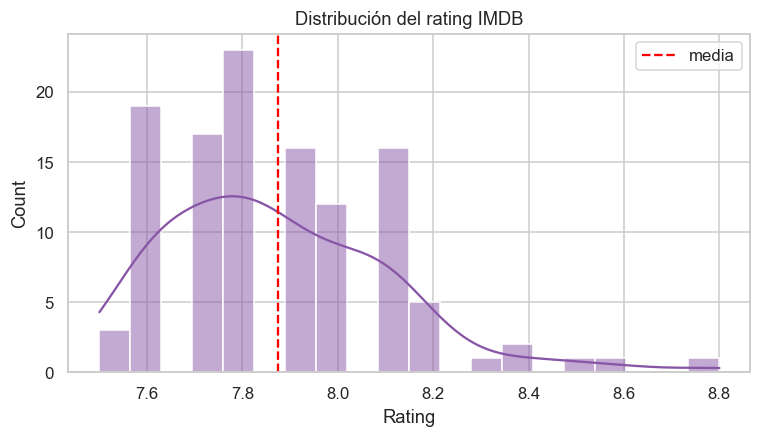

In [11]:
# Distribución del rating
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["Rating"], bins=20, kde=True, color="#8856a7", ax=ax)
ax.axvline(df["Rating"].mean(), color="red", ls="--", label="media")
ax.set_title("Distribución del rating IMDB")
ax.legend()
plt.show()

*Casi todas las películas se concentran entre 7.6 y 8.0 de rating; muy pocas superan 8.4.
La distribución tiene asimetría positiva y la media (línea roja) ronda 7.9. Es un dataset
de films ya "prestigiosos", con poco rango de rating.*

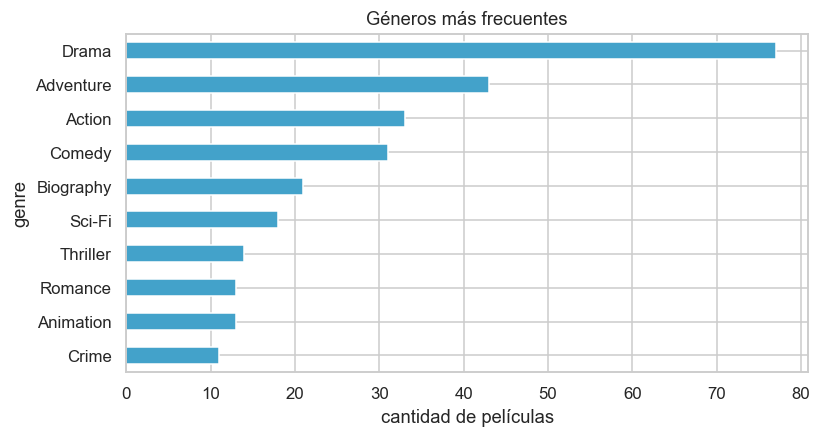

In [12]:
# Géneros más frecuentes
fig, ax = plt.subplots(figsize=(8, 4))
top_generos.sort_values().plot.barh(color="#43a2ca", ax=ax)
ax.set_title("Géneros más frecuentes")
ax.set_xlabel("cantidad de películas")
plt.show()

*Drama es por lejos el género más frecuente (77 películas), seguido de Adventure y Action.
Como cada película puede tener varios géneros (relación 1-a-muchos), la suma de las barras
supera la cantidad total de films.*

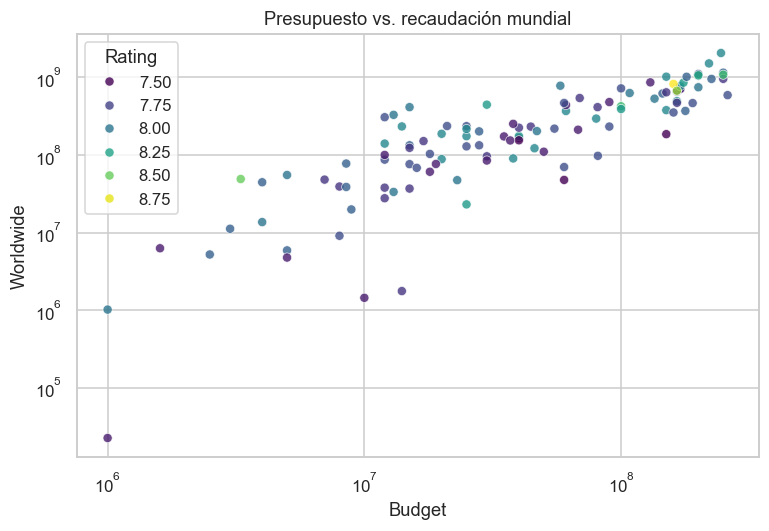

In [13]:
# Presupuesto vs recaudación mundial (escala log)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="Budget", y="Worldwide", hue="Rating",
                palette="viridis", alpha=0.8, ax=ax)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Presupuesto vs. recaudación mundial")
plt.show()

*En escala logarítmica se ve una relación positiva clara: a mayor presupuesto, mayor
recaudación mundial. El color (rating) no muestra un patrón marcado con la taquilla:
películas caras y taquilleras no son necesariamente las mejor puntuadas.*

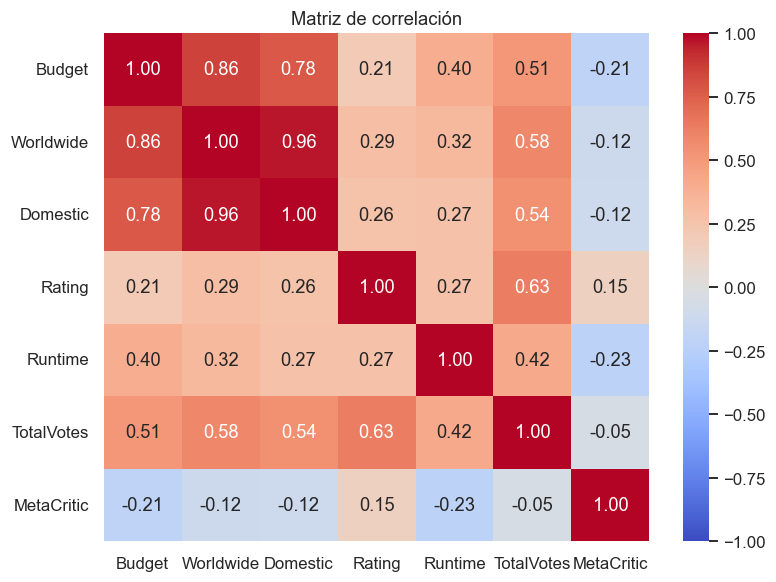

In [14]:
# Heatmap de correlación
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación")
plt.show()

*Budget y Worldwide están muy correlacionados (0.86), y Worldwide con Domestic casi de
forma perfecta (0.96). El rating correlaciona poco con la plata y algo más con la cantidad
de votos (0.63). MetaCritic aporta correlaciones bajas o negativas con lo comercial.*

## 7. Resumen para las diapositivas

In [15]:
resumen = {
    "peliculas": len(df),
    "columnas_totales": imdb.shape[1] + 2,  # IMDB + Domestic/Worldwide
    "num_numericas": df.select_dtypes("number").shape[1],
    "generos_unicos": genre[genre["genre"] != ""]["genre"].nunique(),
    "nulos_MetaCritic": int(df["MetaCritic"].isna().sum()),
    "nulos_Budget": int(df["Budget"].isna().sum()),
    "nulos_Runtime": int(df["Runtime"].isna().sum()),
    "generos_vacios": int((genre["genre"] == "").sum()),
    "top_genero": top_generos.index[0],
    "mas_votada": df.loc[df["TotalVotes"].idxmax(), "Title"],
    "mayor_recaudacion": df.loc[df["Worldwide"].idxmax(), "Title"],
    "rating_promedio": round(df["Rating"].mean(), 1),
}
for k, v in resumen.items():
    print(f"{k}: {v}")

peliculas: 117
columnas_totales: 54
num_numericas: 7
generos_unicos: 20
nulos_MetaCritic: 7
nulos_Budget: 3
nulos_Runtime: 21
generos_vacios: 41
top_genero: Drama
mas_votada: Inception (2010)
mayor_recaudacion: Star Wars: The Force Awakens (2015)
rating_promedio: 7.9
